In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import yaml
from PIL import Image, ImageDraw, ImageFont

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.build import build_finetune_model
from src.finetune.checkpoint import load_trainable_state
from src.predict.grid import GridPredictor
from src.predict.single import SinglePredictor

CONFIG_PATH = ROOT / 'config/finetune_test.yaml'
IMAGE_PATH = ROOT / 'asset/frog_tgt.jpg'
LORA_PATH = None
COND = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = yaml.safe_load(CONFIG_PATH.read_text())
model_config = dict(config['model'])
model_config['path'] = str(ROOT / model_config['path'])
model_config['device'] = device
model = build_finetune_model(model_config)
if LORA_PATH is not None:
    checkpoint = torch.load(LORA_PATH, map_location='cpu', weights_only=False)
    load_trainable_state(model, checkpoint['model'])
model.eval()

single = SinglePredictor(model, device=device, cond=COND)
predictor = GridPredictor(single, tiles=(1, 2), points_per_side=(10, 10), batch_size=4)


In [2]:
image = Image.open(IMAGE_PATH).convert('RGB')
objects = predictor.predict(image)
{
    'device': str(device),
    'cond': COND,
    'masks': len(objects),
    'scores': [round(float(obj['metrics']['score']), 3) for obj in objects],
}


{'device': 'cuda',
 'cond': 0,
 'masks': 25,
 'scores': [2.922,
  2.672,
  2.625,
  2.328,
  2.234,
  2.172,
  2.109,
  2.062,
  2.062,
  2.016,
  1.938,
  1.938,
  1.547,
  1.438,
  1.391,
  1.344,
  2.906,
  2.562,
  2.234,
  2.125,
  1.961,
  1.906,
  1.695,
  1.195,
  0.209]}

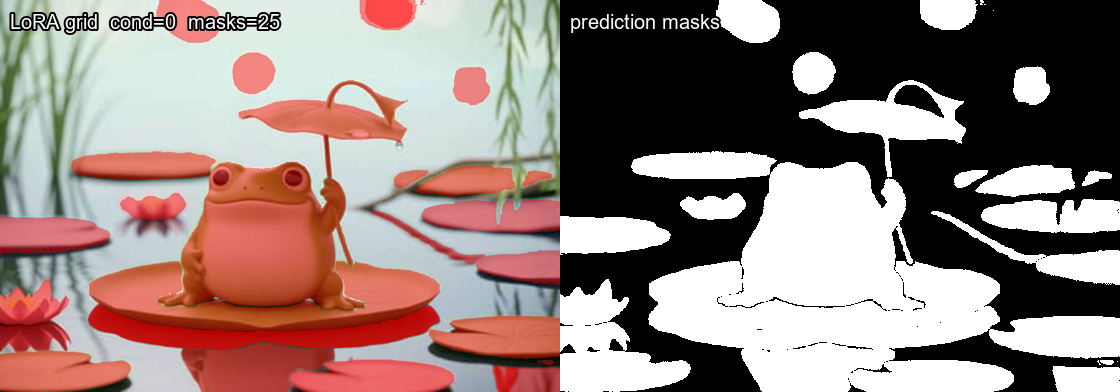

In [3]:
overlay = np.asarray(image, dtype=np.float32).copy()
union = np.zeros((image.height, image.width), dtype=bool)
for obj in objects:
    x0, y0, x1, y1 = obj['box']
    mask = np.zeros_like(union)
    mask[y0:y1, x0:x1] = np.asarray(obj['roi'], dtype=bool)
    union |= mask
    overlay[mask] = overlay[mask] * 0.55 + np.array((255, 0, 0)) * 0.45

left = Image.fromarray(overlay.astype('uint8'))
right = Image.fromarray((union * 255).astype('uint8')).convert('RGB')
height = round(image.height * 560 / image.width)
left = left.resize((560, height))
right = right.resize((560, height), Image.Resampling.NEAREST)
font = ImageFont.truetype('arial.ttf', 20)
ImageDraw.Draw(left).text((10, 10), f'LoRA grid  cond={COND}  masks={len(objects)}', font=font, fill='white', stroke_width=2, stroke_fill='black')
ImageDraw.Draw(right).text((10, 10), 'prediction masks', font=font, fill='white', stroke_width=2, stroke_fill='black')
sheet = Image.new('RGB', (1120, height), 'black')
sheet.paste(left, (0, 0))
sheet.paste(right, (560, 0))
sheet
